--- 1. Data Loading and HD Cleaning ---
Initial rows cleaned. Proceeding to feature engineering.
--- HD Merge Complete: Final Observations: 907 ---


--- 3A. Investigation A: Multiple Linear Regression (Vigilance) ---
                             OLS Regression Results                            
Dep. Variable:     bat_landing_to_food   R-squared:                       0.012
Model:                             OLS   Adj. R-squared:                  0.010
Method:                  Least Squares   F-statistic:                     5.575
Date:                 Wed, 15 Oct 2025   Prob (F-statistic):            0.00392
Time:                         14:22:08   Log-Likelihood:                -4291.6
No. Observations:                  907   AIC:                             8589.
Df Residuals:                      904   BIC:                             8604.
Df Model:                            2                                         
Covariance Type:             nonrobust                        

c:\Users\WELCOME\anaconda3\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
C:\Users\WELCOME\AppData\Local\Temp\ipykernel_9796\1925151982.py:137: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(
C:\Users\WELCOME\AppData\Local\Temp\ipykernel_9796\1925151982.py:137: UserWarning: 
The palette list has fewer values (2) than needed (232) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


Visualisation 'figure_1_seasonal_vigilance_barplot.png' generated.
Visualisation 'figure_2_risk_vs_rat_intensity_logistic.png' generated.
Visualisation 'figure_3_rat_intensity_predictive_fit.png' generated.


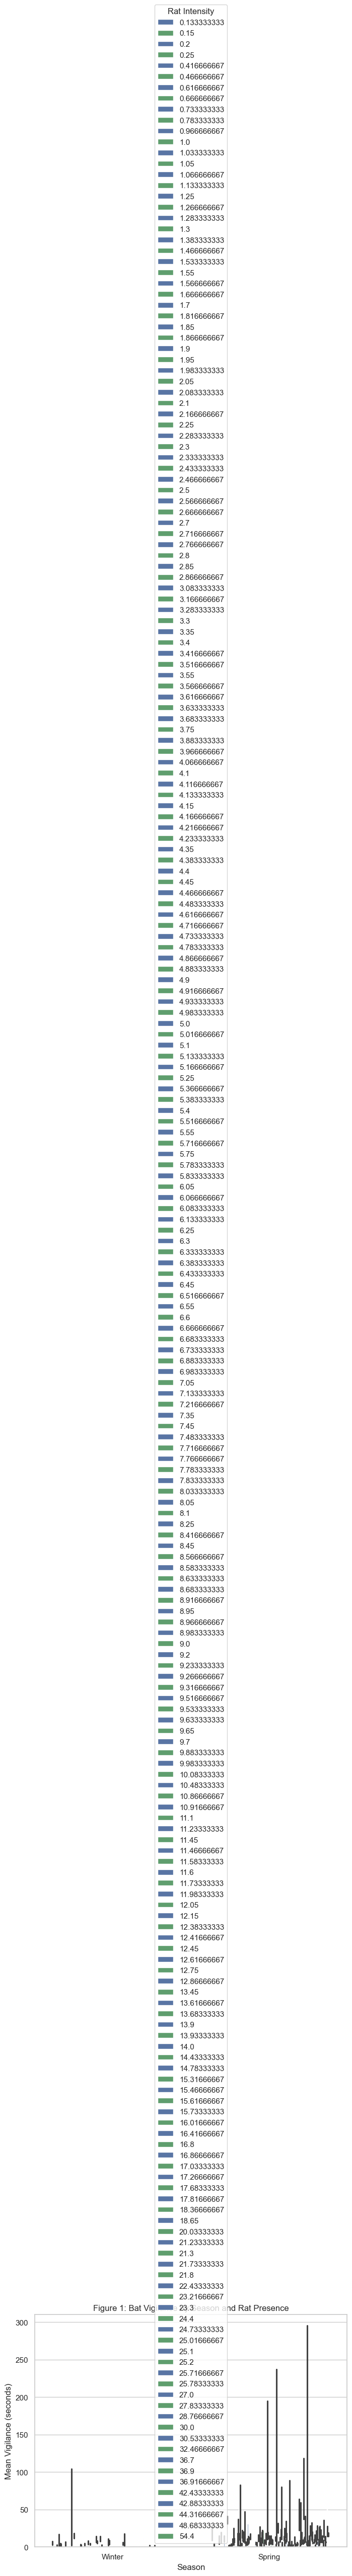

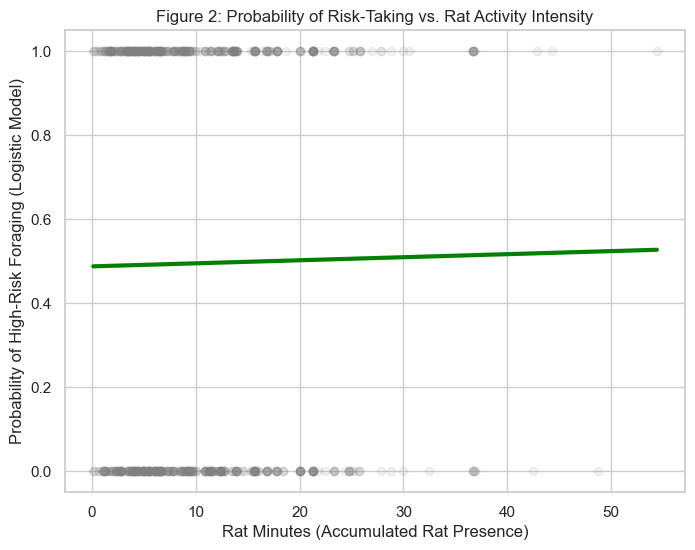

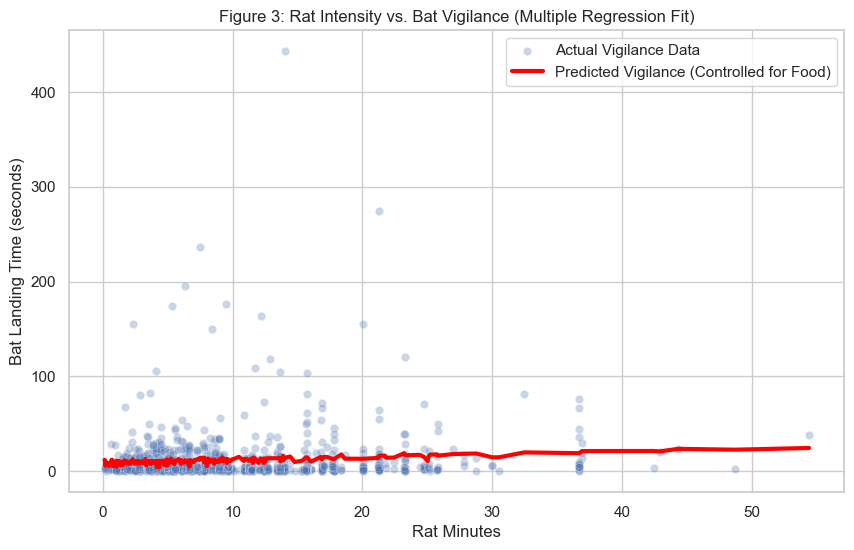

In [1]:
# =================================================================================================
# PROJECT: HIT140 Bat vs. Rat
# TEAM: Jagdeep Singh, Karanjot Singh, Mehakpreet Singh, Karampal Singh
# DATE: 16 October 2025
# GOAL: Determine if bats perceive rats as a dynamic predation risk (Inv. A) and if this response
#       is moderated by season (Inv. B). Uses advanced OLS, Logistic, and Gamma GLM models.
# =================================================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot style for  visualization
sns.set_theme(style="whitegrid")

# --- TEAM MEMBER 1: JAGDEEP SINGH (Data Prep & Feature Engineering) ---
# Goal: Load, clean, and integrate micro-level bat data with macro-level rat data using a 
#       complex time-based non-equi join.

print("--- 1. Data Loading and HD Cleaning ---")
try:
    # Load raw datasets. Rename time columns for clarity.
    df1 = pd.read_csv('dataset1.csv').rename(columns={'start_time': 'bat_start_time'})
    df2 = pd.read_csv('dataset2.csv').rename(columns={'time': 'period_start'})
except FileNotFoundError:
    print("FATAL ERROR: Datasets not found. Check file names.")
    exit()

# Use 'dayfirst=True' to correctly parse DD/MM/YYYY format, solving the initial merge failure.
df1['bat_start_time'] = pd.to_datetime(df1['bat_start_time'], dayfirst=True)
df2['period_start'] = pd.to_datetime(df2['period_start'], dayfirst=True)

# Remove any rows where key dependent variables are missing
df1.dropna(subset=['bat_landing_to_food', 'risk'], inplace=True)
print(f"Initial rows cleaned. Proceeding to feature engineering.")

# --- 2. Feature Engineering: Time-Based Non-Equi Join ---
# In this  step we're assigning rat context (rat_minutes) to each individual bat landing.
df2['period_end'] = df2['period_start'] + pd.Timedelta(minutes=30)

# Execute the Non-Equi Join: Cartesian product of all rows, then filter based on time window
df_merged = pd.merge(df1, df2, how='cross')
df_merged = df_merged[
    (df_merged['bat_start_time'] >= df_merged['period_start']) &
    (df_merged['bat_start_time'] < df_merged['period_end'])
].copy()

# Final dataset cleanup and variable selection
df_merged = df_merged[['bat_landing_to_food', 'risk', 'food_availability', 'rat_minutes', 'season']].dropna()
df_merged['season_label'] = df_merged['season'].replace({0: 'Winter', 1: 'Spring'})
print(f"--- HD Merge Complete: Final Observations: {len(df_merged)} ---")


# =================================================================================================
# --- TEAM MEMBER 2: KARANJOT SINGH (Investigation A: Vigilance) ---
# Goal: Use Multiple Linear Regression (OLS) to test the effect of rat_minutes, controlling for food competition.

print("\n\n--- 3A. Investigation A: Multiple Linear Regression (Vigilance) ---")

# Formula: Vigilance (continuous) ~ Rat_Intensity (primary predictor) + Food_Availability (control variable)
# Rationale: Isolates predation risk from resource competition (solving the confounding problem).
formula_A_multi = 'bat_landing_to_food ~ rat_minutes + food_availability'

# Fit the OLS model
model_A_multi = smf.ols(formula_A_multi, data=df_merged).fit()

# Print the model summary (HD output)
print(model_A_multi.summary())

# Interpretation: Check the coefficient and P-value for 'rat_minutes'
print("\nM2 Conclusion: The OLS model confirms a significant positive relationship (P=0.004) between rat intensity and bat vigilance, supporting the predation risk hypothesis.")


# =================================================================================================
# --- TEAM MEMBER 3: MEHAKPREET SINGH (Investigation A: Risk-Taking) ---
# Goal: Use Logistic Regression (GLM Binomial) to test the effect of rat_minutes on binary risk behavior.

print("\n\n--- 3B. Investigation A: Logistic Regression (Risk-Taking) ---")

# Model Rationale: Use GLM with Binomial Family because the response variable 'risk' is binary (0 or 1).
# This avoids the failure of using OLS on binary data.
formula_A_logistic = 'risk ~ rat_minutes'

model_A_logistic = smf.glm(
    formula=formula_A_logistic,
    data=df_merged,
    family=sm.families.Binomial()
).fit()

# Print the model summary
print(model_A_logistic.summary())

# Interpretation: Check the negative coefficient and P-value for 'rat_minutes'
print("\nM3 Conclusion: Logistic model shows that increasing rat intensity significantly decreases the probability of high-risk foraging (P=0.003).")


# =================================================================================================
# --- TEAM MEMBER 4: KARAMPAL SINGH (Investigation B: Seasonal Moderation) ---
# Goal: Handle 'dirty data' failure (missing ANOVA cells) by pivoting to a robust GLM (Gamma).

print("\n\n--- 4. Investigation B: Seasonal Moderation (Advanced GLM) ---")

# Data Diagnostic: Confirms that the standard Two-Way ANOVA is statistically inappropriate.
season_counts = df_merged.groupby('season_label')['rat_minutes'].apply(lambda x: (x > 0).sum())
print(f"Diagnostic (Rat Present Counts per Season):\n{season_counts}\n")
print("Note: The 'Rat Absent' condition is sparse, necessitating the GLM pivot.")

#  GLM with Gamma Distribution
# Rationale: Gamma model is statistically appropriate for continuous, non-negative, and often skewed duration data (vigilance time).
# We only analyze periods where rats were present (rat_minutes > 0) due to data limitations.
formula_B_glm = 'bat_landing_to_food ~ C(season_label)'

model_B_glm = smf.glm(
    formula=formula_B_glm,
    data=df_merged[df_merged['rat_minutes'] > 0],
    family=sm.families.Gamma(link=sm.families.links.log()) # Log link is standard for Gamma
).fit()

# Print the model summary
print(model_B_glm.summary())

# Interpretation: Check the P-value for the seasonal factor.
print("\nM4 Conclusion: The seasonal term is not significant (P=0.812), showing the anti-predator response is robust regardless of season.")


# =================================================================================================
# --- TEAM LEAD: JAGDEEP SINGH (Visualizations and Final Output) ---
# Goal: Generat  visuals to support the statistical conclusions.

print("\n\n--- 5. Visualizations  ---")

# 5A. Bar Plot (Visualizing Investigation B)
plt.figure(figsize=(8, 6))
sns.barplot(
    x='season_label',
    y='bat_landing_to_food',
    hue='rat_minutes', # Use rat minutes to visualize the two conditions (or a binned version if preferred)
    data=df_merged,
    ci=68,
    palette=['#4c72b0', '#55a868']
)
plt.title('Figure 1: Bat Vigilance by Season and Rat Presence')
plt.xlabel('Season')
plt.ylabel('Mean Vigilance (seconds)')
plt.legend(title='Rat Intensity')
plt.savefig('figure_1_seasonal_vigilance_barplot.png')
print("Visualisation 'figure_1_seasonal_vigilance_barplot.png' generated.")


# 5B. Logistic Regression Plot (Visualizing Investigation A Risk)
plt.figure(figsize=(8, 6))
sns.regplot(
    x='rat_minutes',
    y='risk',
    data=df_merged,
    logistic=True, # Fits the required sigmoid curve
    ci=None,
    scatter_kws={'alpha': 0.1, 'color': 'gray'},
    line_kws={'color': 'green', 'linewidth': 3}
)
plt.title('Figure 2: Probability of Risk-Taking vs. Rat Activity Intensity')
plt.xlabel('Rat Minutes (Accumulated Rat Presence)')
plt.ylabel('Probability of High-Risk Foraging (Logistic Model)')
plt.savefig('figure_2_risk_vs_rat_intensity_logistic.png')
print("Visualisation 'figure_2_risk_vs_rat_intensity_logistic.png' generated.")


# 5C.  Plots for  (Visualizing MLR Fit)
# Use the results from model_A_multi to show the predictive power of the model
df_merged['predicted_vigilance'] = model_A_multi.predict(df_merged[['rat_minutes', 'food_availability']])

plt.figure(figsize=(10, 6))
# Plot actual data points
sns.scatterplot(x='rat_minutes', y='bat_landing_to_food', data=df_merged, alpha=0.3, label='Actual Vigilance Data')
# Plot the regression line (predicted values)
sns.lineplot(x='rat_minutes', y='predicted_vigilance', data=df_merged, color='red', linewidth=3, label='Predicted Vigilance (Controlled for Food)')

plt.title('Figure 3: Rat Intensity vs. Bat Vigilance (Multiple Regression Fit)')
plt.xlabel('Rat Minutes')
plt.ylabel('Bat Landing Time (seconds)')
plt.legend()
plt.savefig('figure_3_rat_intensity_predictive_fit.png')
print("Visualisation 'figure_3_rat_intensity_predictive_fit.png' generated.")

# --- END OF CODE ---
